In [14]:
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(readr)
  library(tibble)

In [21]:
ENRICH_DIR <- "/home/dh2226/scratch_pi_cs3222/dh2226/20261005/enrichment"            # directory containing the aggregate_enrich outputs
OUTDIR     <- "enrichment_figs"
STRATUM    <- "all"          # stratum used for the single-stratum plots
SIG_CUT    <- 0.05           # q cutoff for stars
LFC_LIM    <- 3              # colour scale limit for log2 fold enrichment
MIN_REGIONS_PER_GENE <- 1   # genes with fewer perturbed regions are dropped from the violins

dir.create(OUTDIR, showWarnings = FALSE, recursive = TRUE)
rd <- function(f) read_tsv(file.path(ENRICH_DIR, f), show_col_types = FALSE)

by_set <- rd("enrichment_by_set.tsv") |>
  mutate(log2fe = log2(pmax(fold_enrichment, 2^-LFC_LIM)),
         star = case_when(q_enrich < SIG_CUT ~ "*", q_deplete < SIG_CUT ~ "\u2020", TRUE ~ ""))
cat("strata:", paste(unique(by_set$stratum), collapse = ", "), "\n")
glimpse(by_set)

strata: all, annotation=TSS_boundary, annotation=TSS_proximal, annotation=distal, direction=decrease, direction=increase, direction=mixed, is_distal_enh=False 
Rows: 72
Columns: 19
$ stratum         <chr> "all", "all", "all", "all", "all", "all", "all", "all"…
$ annotation      <chr> "astro_h3k27ac_peak", "astro_h3k27ac_bw", "SN_h3k27ac_…
$ n_regions       <dbl> 7341, 7341, 7341, 7341, 7341, 7341, 7341, 7341, 7341, …
$ n_genes         <dbl> 507, 507, 507, 507, 507, 507, 507, 507, 507, 424, 424,…
$ n_overlap       <dbl> 2192, 2649, 1809, 2948, 2846, 3687, 2051, 3426, 2846, …
$ frac_overlap    <dbl> 0.2985969, 0.3608500, 0.2464242, 0.4015802, 0.3876856,…
$ null_mean_frac  <dbl> 0.2715265, 0.3358696, 0.2282782, 0.3903659, 0.3653327,…
$ null_sd_frac    <dbl> 0.003855048, 0.004244258, 0.003612229, 0.004274151, 0.…
$ fold_enrichment <dbl> 1.099697, 1.074375, 1.079491, 1.028728, 1.061185, 1.05…
$ z               <dbl> 7.022073, 5.885690, 5.023499, 2.623743, 5.324844, 5.58…
$ p_enrich        <

In [ ]:
# Fold enrichment across bigwig tracks, grouped by assay
ASSAY_LABELS <- c(h3k27ac = "H3K27ac", h3k4me1 = "H3K4me1", atac = "ATAC", chip = "ChIP")

d_bw <- by_set |> filter(stratum == STRATUM, source == "bigwig")
stopifnot("no bigwig sets found for this stratum" = nrow(d_bw) > 0)

d_bw <- d_bw |>
  mutate(assay_lab = unname(ifelse(assay %in% names(ASSAY_LABELS), ASSAY_LABELS[assay], assay)),
         assay_lab = factor(assay_lab, levels = unique(assay_lab)),   # panels in manifest order
         track     = unname(mapply(function(a, s) sub(paste0("_", s, "(_.*)?$"), "", a),
                                   annotation, assay)),                # astro_h3k27ac_bw -> astro
         lab       = sprintf("%.2f%s", fold_enrichment, star))
trk_ord <- unique(d_bw$track[order(d_bw$celltype, d_bw$track)])
d_bw <- d_bw |> mutate(track = factor(track, levels = rev(trk_ord)))   # same top-to-bottom order in every panel

p_bw <- ggplot(d_bw, aes(y = track)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.4) +
  geom_linerange(aes(xmin = 1, xmax = fold_enrichment), color = "grey60", linewidth = 1) +
  geom_point(aes(x = fold_enrichment, fill = celltype),
             shape = 21, size = 4.5, color = "grey20", stroke = 0.5) +
  geom_text(data = function(d) d[d$fold_enrichment >= 1, ],
            aes(x = fold_enrichment, label = lab), hjust = -0.35, size = 3.6, color = "grey15") +
  geom_text(data = function(d) d[d$fold_enrichment < 1, ],
            aes(x = fold_enrichment, label = lab), hjust = 1.35, size = 3.6, color = "grey15") +
  facet_grid(assay_lab ~ ., scales = "free_y", space = "free_y", switch = "y") +
  scale_fill_brewer(palette = "Set2", name = NULL) +
  scale_x_continuous(expand = expansion(mult = c(0.12, 0.2))) +
  labs(x = "fold enrichment over null (1 = no enrichment)", y = NULL,
       title = sprintf("Fold enrichment by bigwig track, grouped by assay (stratum: %s)", STRATUM),
       subtitle = sprintf("* q_enrich < %g, † q_deplete < %g; dashed line = null; n = %s regions",
                          SIG_CUT, SIG_CUT, format(unique(d_bw$n_regions)[1], big.mark = ","))) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), panel.grid.major.y = element_blank(),
        panel.spacing.y = unit(0.8, "lines"),
        strip.placement = "outside",
        strip.text.y.left = element_text(angle = 0, hjust = 1, face = "bold"),
        plot.title.position = "plot",
        legend.position = "bottom")

h <- 1.8 + 0.45 * nrow(d_bw) + 0.3 * nlevels(d_bw$assay_lab)
options(repr.plot.width = 8, repr.plot.height = h)
ggsave(file.path(OUTDIR, "fold_enrichment_bigwig_by_assay.pdf"), p_bw, width = 8, height = h, limitsize = FALSE)
p_bw

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '* q_enrich < 0.05, † q_deplete < 0.05; n = 7,341 regions' in 'mbcsToSbcs': for † (U+2020)”


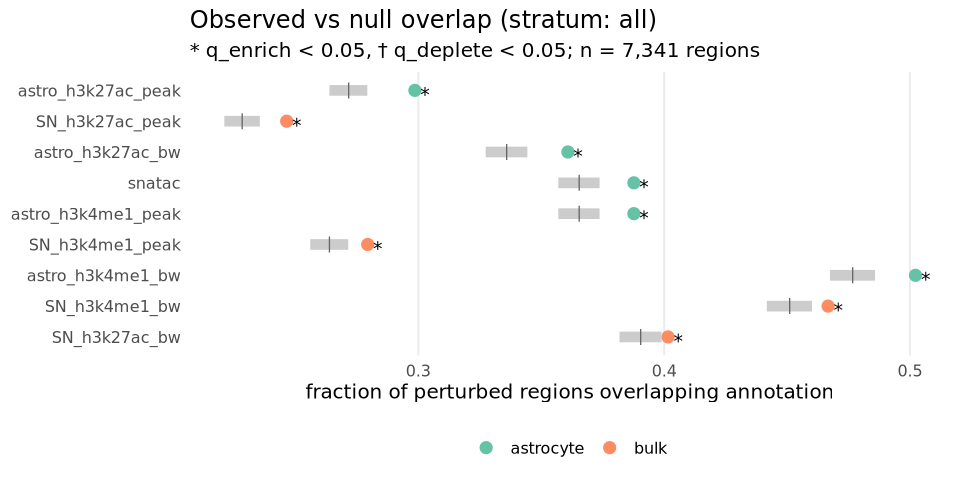

In [22]:
d1 <- by_set |> filter(stratum == STRATUM) |>
  mutate(annotation = reorder(annotation, log2fe))

p_obs_null <- ggplot(d1, aes(y = annotation)) +
  geom_linerange(aes(xmin = pmax(0, null_mean_frac - 2 * null_sd_frac),
                     xmax = null_mean_frac + 2 * null_sd_frac),
                 linewidth = 3, color = "grey80") +
  geom_point(aes(x = null_mean_frac), shape = "|", size = 3, color = "grey40") +
  geom_point(aes(x = frac_overlap, color = celltype), size = 3) +
  geom_text(aes(x = pmax(frac_overlap, null_mean_frac + 2 * null_sd_frac), label = star),
            hjust = -0.6, vjust = 0.75, size = 4) +
  scale_color_brewer(palette = "Set2", name = NULL) +
  labs(x = "fraction of perturbed regions overlapping annotation", y = NULL,
       title = sprintf("Observed vs null overlap (stratum: %s)", STRATUM),
       subtitle = sprintf("* q_enrich < %g, \u2020 q_deplete < %g; n = %s regions",
                          SIG_CUT, SIG_CUT, format(unique(d1$n_regions)[1], big.mark = ","))) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), panel.grid.major.y = element_blank(),
        legend.position = "bottom")

h <- 1.5 + 0.28 * nrow(d1); options(repr.plot.width = 8, repr.plot.height = h)
ggsave(file.path(OUTDIR, "observed_vs_null.pdf"), p_obs_null, width = 8, height = h, limitsize = FALSE)
p_obs_null

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '* q_enrich < 0.05, † q_deplete < 0.05' in 'mbcsToSbcs': for † (U+2020)”


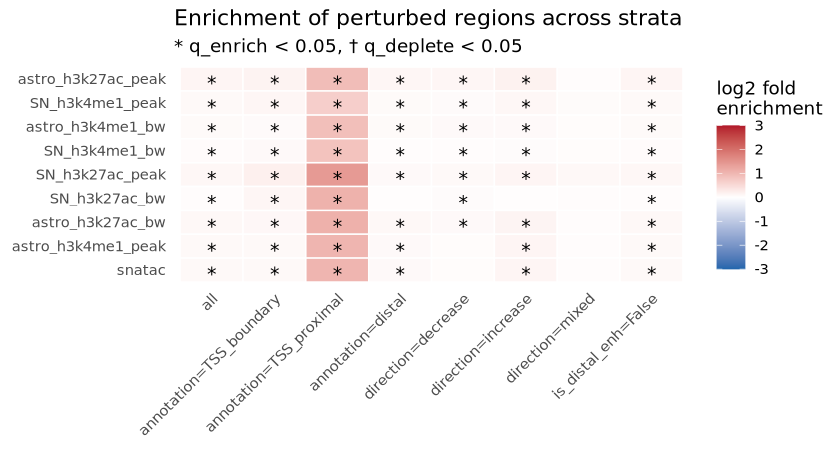

In [17]:
mat <- by_set |> select(annotation, stratum, log2fe) |>
  pivot_wider(names_from = stratum, values_from = log2fe) |>
  column_to_rownames("annotation") |> as.matrix()
mat[is.na(mat)] <- 0
row_ord <- if (nrow(mat) > 1) rownames(mat)[hclust(dist(mat))$order] else rownames(mat)
strata_ord <- c("all", setdiff(colnames(mat), "all"))   # keep 'all' first, rest in file order

hm <- by_set |>
  mutate(annotation = factor(annotation, levels = rev(row_ord)),
         stratum    = factor(stratum, levels = strata_ord))

p_heat <- ggplot(hm, aes(stratum, annotation, fill = log2fe)) +
  geom_tile(color = "white", linewidth = 0.4) +
  geom_text(aes(label = star), vjust = 0.75, size = 4) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", midpoint = 0,
                       limits = c(-LFC_LIM, LFC_LIM), oob = scales::squish,
                       name = "log2 fold\nenrichment") +
  labs(x = NULL, y = NULL, title = "Enrichment of perturbed regions across strata",
       subtitle = sprintf("* q_enrich < %g, \u2020 q_deplete < %g", SIG_CUT, SIG_CUT)) +
  theme_minimal(base_size = 11) +
  theme(panel.grid = element_blank(), axis.text.x = element_text(angle = 45, hjust = 1))

w <- 3 + 0.5 * length(strata_ord); h <- 1.5 + 0.25 * length(row_ord)
options(repr.plot.width = w, repr.plot.height = h)
ggsave(file.path(OUTDIR, "fold_enrichment_heatmap.pdf"), p_heat, width = w, height = h, limitsize = FALSE)
p_heat

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '418 genes with ≥ 5 regions; red diamond = pooled null mean' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


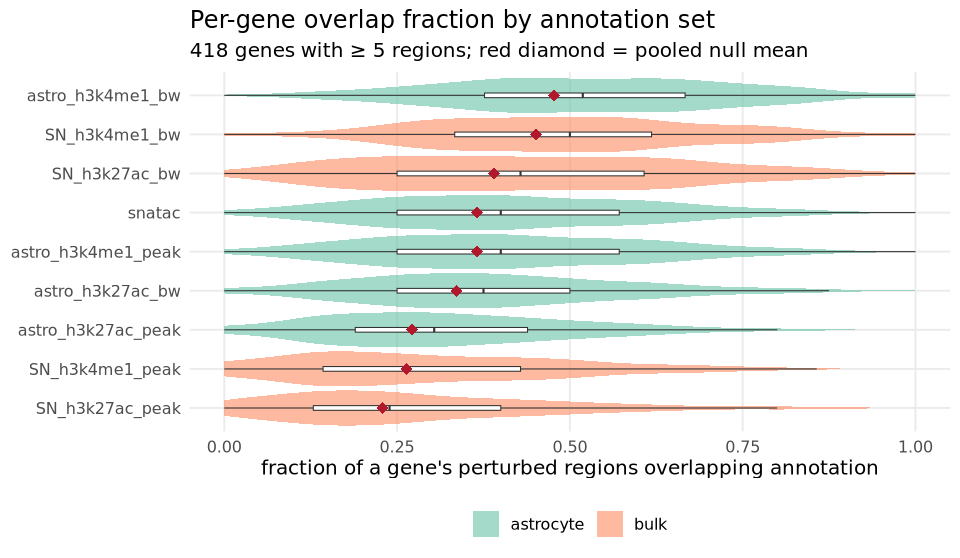

In [18]:
pg <- rd("per_gene_counts.tsv") |>
  pivot_longer(cols = c(starts_with("n_"), -n_regions),
               names_to = "annotation", names_prefix = "n_", values_to = "n_overlap") |>
  filter(n_regions >= MIN_REGIONS_PER_GENE) |>
  mutate(frac = n_overlap / n_regions)

meta <- by_set |> filter(stratum == STRATUM) |>
  select(annotation, celltype, assay, null_mean_frac, frac_overlap)
pg <- inner_join(pg, meta, by = "annotation") |>
  mutate(annotation = reorder(annotation, frac_overlap))

p_violin <- ggplot(pg, aes(x = frac, y = annotation)) +
  geom_violin(aes(fill = celltype), scale = "width", alpha = 0.6, color = NA) +
  geom_boxplot(width = 0.12, outlier.shape = NA, fill = "white", linewidth = 0.3) +
  geom_point(data = distinct(pg, annotation, null_mean_frac),
             aes(x = null_mean_frac), shape = 18, size = 3, color = "#B2182B") +
  scale_fill_brewer(palette = "Set2", name = NULL) +
  labs(x = "fraction of a gene's perturbed regions overlapping annotation", y = NULL,
       title = "Per-gene overlap fraction by annotation set",
       subtitle = sprintf("%d genes with \u2265 %d regions; red diamond = pooled null mean",
                          n_distinct(pg$gene_id), MIN_REGIONS_PER_GENE)) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), legend.position = "bottom")

h <- 1.5 + 0.35 * n_distinct(pg$annotation); options(repr.plot.width = 8, repr.plot.height = h)
ggsave(file.path(OUTDIR, "per_gene_violins.pdf"), p_violin, width = 8, height = h, limitsize = FALSE)
p_violin

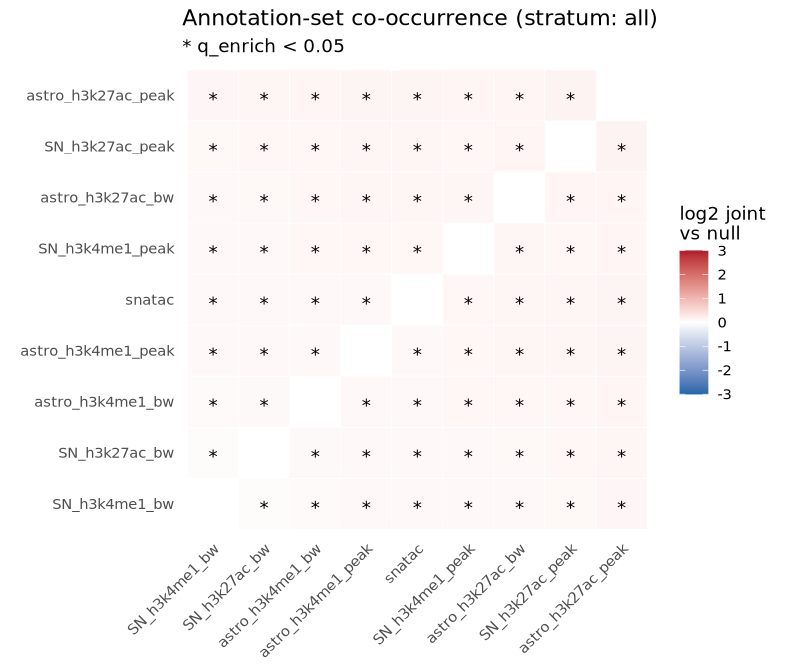

In [19]:
pw <- rd("set_pairwise.tsv") |> filter(stratum == STRATUM) |>
  mutate(lfc  = log2(pmax(fold_vs_null, 2^-LFC_LIM)),
         star = ifelse(q_enrich < SIG_CUT, "*", ""))
pw_sym <- bind_rows(pw, pw |> rename(set_a = set_b, set_b = set_a))
ord <- pw_sym |> group_by(set_a) |> summarise(m = mean(lfc, na.rm = TRUE)) |> arrange(m) |> pull(set_a)
pw_sym <- pw_sym |> mutate(set_a = factor(set_a, levels = ord), set_b = factor(set_b, levels = ord))

p_pair <- ggplot(pw_sym, aes(set_a, set_b, fill = lfc)) +
  geom_tile(color = "white") +
  geom_text(aes(label = star), vjust = 0.75) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", midpoint = 0,
                       limits = c(-LFC_LIM, LFC_LIM), oob = scales::squish,
                       name = "log2 joint\nvs null") +
  labs(x = NULL, y = NULL, title = sprintf("Annotation-set co-occurrence (stratum: %s)", STRATUM),
       subtitle = sprintf("* q_enrich < %g", SIG_CUT)) +
  coord_fixed() +
  theme_minimal(base_size = 11) +
  theme(panel.grid = element_blank(), axis.text.x = element_text(angle = 45, hjust = 1))

s <- 2 + 0.4 * length(ord); options(repr.plot.width = s + 1, repr.plot.height = s)
ggsave(file.path(OUTDIR, "set_pairwise_heatmap.pdf"), p_pair, width = s + 1, height = s, limitsize = FALSE)
p_pair

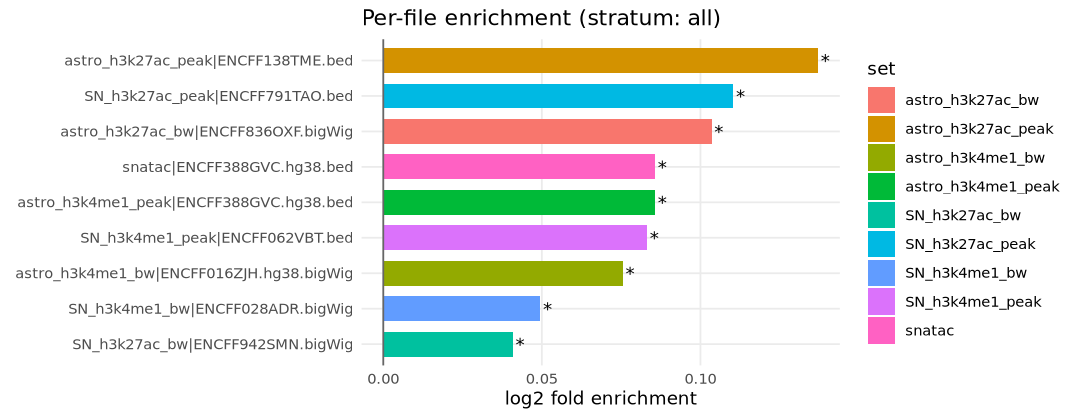

In [20]:
by_file <- rd("enrichment_by_file.tsv") |> filter(stratum == STRATUM) |>
  mutate(log2fe = log2(pmax(fold_enrichment, 2^-LFC_LIM)),
         set = sub("\\|.*$", "", annotation),
         star = ifelse(q_enrich < SIG_CUT, "*", ""),
         annotation = reorder(annotation, log2fe))

p_file <- ggplot(by_file, aes(log2fe, annotation, fill = set)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = star), hjust = -0.3) +
  geom_vline(xintercept = 0, color = "grey40") +
  labs(x = "log2 fold enrichment", y = NULL, fill = "set",
       title = sprintf("Per-file enrichment (stratum: %s)", STRATUM)) +
  theme_minimal(base_size = 11) + theme(panel.grid.minor = element_blank())

h <- 1.5 + 0.22 * nrow(by_file); options(repr.plot.width = 9, repr.plot.height = h)
ggsave(file.path(OUTDIR, "per_file_enrichment.pdf"), p_file, width = 9, height = h, limitsize = FALSE)
p_file